# Daily Challenge: How to Fine-tune LLMs with LoRA

Week 13, Day 2

**Parameter-Efficient Fine-Tuning (PEFT)** methods like **LoRA** adapt a large pre-trained model by training only a small number of extra parameters (low-rank matrices added to some layers) while the original weights stay frozen. This reduces memory, compute and storage: the adapter is a few MB instead of a full copy of the model.

**Goal:** fine-tune `bigscience/bloomz-560m` with LoRA on 10% of the `Abirate/english_quotes` dataset so that it generates quotes, then save the adapter, reload it with `PeftModel.from_pretrained` and generate text.

## 1. Install the necessary libraries

> The hint pins `peft==0.4.0` (2023). That version is no longer compatible with recent versions of `transformers` (including the one pre-installed in Colab), so we install a recent `peft`. The API used below (`LoraConfig`, `get_peft_model`, `PeftModel.from_pretrained`) is the same.

In [1]:
%pip install -q peft datasets accelerate
!mkdir -p cache

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, time, warnings
os.environ["USE_TF"] = "0"              # PyTorch backend only
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")

import torch
import transformers
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()
import peft, datasets
transformers.set_seed(42)
print("transformers", transformers.__version__, "| peft", peft.__version__, "| datasets", datasets.__version__,
      "| GPU:", torch.cuda.is_available())

transformers 4.57.6 | peft 0.21.2 | datasets 4.0.0 | GPU: False


## 2. Load the pre-trained model and its tokenizer

In [3]:
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "bigscience/bloomz-560m"
tokenizer = AutoTokenizer.from_pretrained(model_name)
foundation_model = AutoModelForCausalLM.from_pretrained(model_name)
print(f"{model_name}: {foundation_model.num_parameters():,} parameters")
print(foundation_model.transformer.h[0])   # one transformer block: the attention uses a fused 'query_key_value' linear layer

bigscience/bloomz-560m: 559,214,592 parameters
BloomBlock(
  (input_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
  (self_attention): BloomAttention(
    (query_key_value): Linear(in_features=1024, out_features=3072, bias=True)
    (dense): Linear(in_features=1024, out_features=1024, bias=True)
    (attention_dropout): Dropout(p=0.0, inplace=False)
  )
  (post_attention_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
  (mlp): BloomMLP(
    (dense_h_to_4h): Linear(in_features=1024, out_features=4096, bias=True)
    (gelu_impl): BloomGelu()
    (dense_4h_to_h): Linear(in_features=4096, out_features=1024, bias=True)
  )
)


BLOOMZ-560M is a 560-million-parameter decoder-only (GPT-like) model from BigScience, multitask-fine-tuned to follow prompts. Each of its 24 blocks has a self-attention layer where the query, key and value projections are fused into a single linear layer called **`query_key_value`**: this is the layer we will adapt with LoRA.

Before fine-tuning, let's look at what the original model generates for our prompt:

In [4]:
def generate(model, prompt, max_new_tokens=20):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.5,          # avoid repeating the same words
        eos_token_id=tokenizer.eos_token_id,
        do_sample=False,                 # deterministic (greedy) decoding to compare models fairly
    )
    return tokenizer.batch_decode(outputs, skip_special_tokens=True)

prompts = ["Two things are infinite: ", "Be yourself; ", "Life is like "]
baseline_outputs = {p: generate(foundation_model, p)[0] for p in prompts}
for p, out in baseline_outputs.items():
    print(f"[original model] {out!r}")

[original model] 'Two things are infinite:  the number of people and their numbers'
[original model] 'Be yourself;  you are the only one who can truly know your own strengths and weaknesses.'
[original model] 'Life is like  a dream'


## 3. Load and preprocess the dataset

In [5]:
data = load_dataset("Abirate/english_quotes", split="train[:10%]")  # Sample 10%
print(data)
data = data.map(lambda samples: tokenizer(samples["quote"], truncation=True, max_length=64), batched=True)  # cap long quotes to save memory
train_sample = data.select(range(5))
display(train_sample)
for row in train_sample:
    print(f"{row['quote']}  — {row['author']}  ({len(row['input_ids'])} tokens)")

Dataset({
    features: ['quote', 'author', 'tags'],
    num_rows: 251
})


Dataset({
    features: ['quote', 'author', 'tags', 'input_ids', 'attention_mask'],
    num_rows: 5
})

“Be yourself; everyone else is already taken.”  — Oscar Wilde  (11 tokens)
“I'm selfish, impatient and a little insecure. I make mistakes, I am out of control and at times hard to handle. But if you can't handle me at my worst, then you sure as hell don't deserve me at my best.”  — Marilyn Monroe  (51 tokens)
“Two things are infinite: the universe and human stupidity; and I'm not sure about the universe.”  — Albert Einstein  (21 tokens)
“So many books, so little time.”  — Frank Zappa  (10 tokens)
“A room without books is like a body without a soul.”  — Marcus Tullius Cicero  (13 tokens)


The dataset contains famous quotes with their author and tags; the 10% sample has **251 quotes**. We only use the `quote` column: each quote is tokenized into `input_ids` and an `attention_mask`, the format expected by the model. The language-modeling collator used later will copy `input_ids` into `labels`, so the model learns to predict each next token of the quotes (causal language modeling), i.e. to write in the style of these quotes.

## 4–5. Configure LoRA and apply it to the model

In [6]:
import peft
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=1,                                  # rank of the low-rank update matrices
    lora_alpha=1,                         # a scaling factor that adjusts the magnitude of the weight matrix. Usually set to 1
    target_modules=["query_key_value"],   # the fused attention projection of every BLOOM block
    lora_dropout=0.05,                    # dropout on the LoRA branch to limit overfitting
    bias="none",                          # this specifies if the bias parameter should be trained.
    task_type="CAUSAL_LM"
)

# Add the adapter layers to the foundation model to be trained
peft_model = get_peft_model(foundation_model, lora_config)
print(peft_model.print_trainable_parameters())
print(peft_model.base_model.model.transformer.h[0].self_attention.query_key_value)

trainable params: 98,304 || all params: 559,312,896 || trainable%: 0.0176
None
lora.Linear(
  (base_layer): Linear(in_features=1024, out_features=3072, bias=True)
  (lora_dropout): ModuleDict(
    (default): Dropout(p=0.05, inplace=False)
  )
  (lora_A): ModuleDict(
    (default): Linear(in_features=1024, out_features=1, bias=False)
  )
  (lora_B): ModuleDict(
    (default): Linear(in_features=1, out_features=3072, bias=False)
  )
  (lora_embedding_A): ParameterDict()
  (lora_embedding_B): ParameterDict()
  (lora_magnitude_vector): ModuleDict()
)


With **rank r = 1** on the `query_key_value` layers (1024 → 3072) of the 24 blocks, LoRA adds only `24 × 1 × (1024 + 3072) = 98,304` trainable parameters: **about 0.02% of the 559 million parameters**, which all stay frozen. `print_trainable_parameters()` prints this summary (and returns `None`, hence the extra `None` line). The printed layer shows that each `query_key_value` is now a `lora.Linear` wrapping the original layer with two small matrices `lora_A` (1024 → 1) and `lora_B` (1 → 3072).

## 6–7. Set up the training arguments and train with `Trainer`

> **Learning rate.** The hint suggests `3e-2`. In our tests this value made the training **diverge**: the loss went from 5.9 up to 49 and the model ended up generating random multilingual tokens. LoRA does allow higher learning rates than full fine-tuning (typically 1e-4 to 1e-3, versus 1e-5 for full fine-tuning), but 3e-2 is too high for BLOOMZ in full precision on this tiny dataset. We therefore use **`3e-3`**, still about 100 times higher than a typical full fine-tuning learning rate, which trains smoothly.

In [7]:
import transformers
from transformers import TrainingArguments, Trainer
import os

output_directory = os.path.join("cache/working", "peft_lab_outputs")
training_args = TrainingArguments(
    report_to="none",
    output_dir=output_directory,
    auto_find_batch_size=True,        # find the largest batch size that fits in memory
    per_device_train_batch_size=4,    # starting batch size (BLOOM's 250k-token vocabulary makes the logits large)
    learning_rate=3e-3,               # Higher learning rate than full fine-tuning (3e-2 diverged, see below).
    num_train_epochs=2,
    logging_steps=4,
    save_strategy="no",
    use_cpu=not torch.cuda.is_available(),
    seed=42,
)

trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=data,
    data_collator=transformers.DataCollatorForLanguageModeling(tokenizer, mlm=False)
)
t0 = time.time()
trainer.train()
print(f"Training time: {(time.time() - t0) / 60:.1f} min")

{'loss': 3.7946, 'grad_norm': 0.8461192846298218, 'learning_rate': 0.0029285714285714284, 'epoch': 0.06349206349206349}


{'loss': 3.433, 'grad_norm': 0.8965544700622559, 'learning_rate': 0.002833333333333333, 'epoch': 0.12698412698412698}


{'loss': 3.4045, 'grad_norm': 1.2618045806884766, 'learning_rate': 0.0027380952380952383, 'epoch': 0.19047619047619047}


{'loss': 3.2036, 'grad_norm': 2.367147445678711, 'learning_rate': 0.002642857142857143, 'epoch': 0.25396825396825395}


{'loss': 2.9513, 'grad_norm': 3.514997720718384, 'learning_rate': 0.0025476190476190477, 'epoch': 0.31746031746031744}


...

{'loss': 2.818, 'grad_norm': 1.2622315883636475, 'learning_rate': 0.00035714285714285714, 'epoch': 1.7777777777777777}


{'loss': 2.8534, 'grad_norm': 5.2616496086120605, 'learning_rate': 0.0002619047619047619, 'epoch': 1.8412698412698414}


{'loss': 2.852, 'grad_norm': 1.4678372144699097, 'learning_rate': 0.00016666666666666666, 'epoch': 1.9047619047619047}


{'loss': 2.7777, 'grad_norm': 1.2540732622146606, 'learning_rate': 7.142857142857142e-05, 'epoch': 1.9682539682539684}


{'train_runtime': 240.51, 'train_samples_per_second': 2.087, 'train_steps_per_second': 0.524, 'train_loss': 3.0327057043711343, 'epoch': 2.0}
Training time: 4.0 min


,step,epoch,loss
0,4,0.063492,3.7946
1,8,0.126984,3.4330
2,12,0.190476,3.4045
3,16,0.253968,3.2036
4,20,0.317460,2.9513
5,24,0.380952,3.4121
6,28,0.444444,3.0660
7,32,0.507937,3.0705
8,36,0.571429,3.1036
9,40,0.634921,3.0378


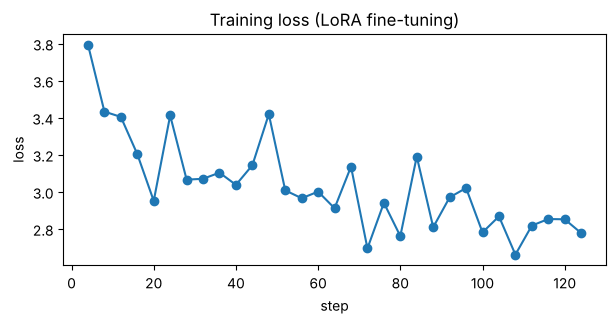

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
logs = pd.DataFrame([l for l in trainer.state.log_history if 'loss' in l])
display(logs[['step', 'epoch', 'loss']])
logs.plot(x='step', y='loss', marker='o', figsize=(7, 3), title='Training loss (LoRA fine-tuning)', legend=False)
plt.ylabel('loss'); plt.show()

## 8. Save the fine-tuned LoRA model

In [9]:
import time

time_now = time.strftime("%Y%m%d-%H%M%S")
peft_model_path = os.path.join(output_directory, f"peft_model_{time_now}")
trainer.model.save_pretrained(peft_model_path)

print("Saved to:", peft_model_path)
for f in sorted(os.listdir(peft_model_path)):
    print(f"  {f}: {os.path.getsize(os.path.join(peft_model_path, f)) / 1024:.1f} KB")

Saved to: cache/working/peft_lab_outputs/peft_model_20261009-004613
  README.md: 5.1 KB
  adapter_config.json: 1.1 KB
  adapter_model.safetensors: 390.8 KB


Only the **adapter** is saved: `adapter_config.json` (the LoRA configuration and the name of the base model) and `adapter_model.safetensors` with the LoRA weights, a few hundred KB, compared with about 1.1 GB for the full BLOOMZ-560M model. To use it, we load the base model and attach the adapter.

## 9. Load the saved LoRA model for inference

In [10]:
from peft import PeftModel

# Load the PEFT model using pre-defined LoRA configs and foundation model. We set `is_trainable=False` to avoid further training.
base_model = AutoModelForCausalLM.from_pretrained(model_name)
loaded_model = PeftModel.from_pretrained(base_model, peft_model_path, is_trainable=False)
loaded_model.eval()
loaded_model.print_trainable_parameters()   # 0 trainable parameters: inference only

trainable params: 0 || all params: 559,312,896 || trainable%: 0.0000


## 10. Generate text with the fine-tuned model

In [11]:
# Generate output tokens
inputs = tokenizer("Two things are infinite: ", return_tensors="pt")
outputs = loaded_model.generate(
    input_ids=inputs["input_ids"],
    attention_mask=inputs["attention_mask"],
    max_new_tokens=20,
    repetition_penalty=1.5,
    eos_token_id=tokenizer.eos_token_id,
    do_sample=False,
)

print(tokenizer.batch_decode(outputs, skip_special_tokens=True))

['Two things are infinite:  time and space. Time is the only thing that can be measured, but it cannot measure anything else']


In [12]:
# Before vs after fine-tuning on several prompts
for p in prompts:
    print(f"Prompt: {p!r}")
    print(f"  original model : {baseline_outputs[p]!r}")
    print(f"  LoRA fine-tuned: {generate(loaded_model, p)[0]!r}\n")

Prompt: 'Two things are infinite: '
  original model : 'Two things are infinite:  the number of people and their numbers'


  LoRA fine-tuned: 'Two things are infinite:  time and space. Time is the only thing that can be measured, but it cannot measure anything else'

Prompt: 'Be yourself; '
  original model : 'Be yourself;  you are the only one who can truly know your own strengths and weaknesses.'


  LoRA fine-tuned: 'Be yourself;  you are the only one who can truly understand what it is like to be a person.” “'

Prompt: 'Life is like '
  original model : 'Life is like  a dream'


  LoRA fine-tuned: 'Life is like  a book, which you read and then forget.” “It’s not about the author but how'



## Results and conclusion

**Training.** With LoRA (r = 1 on the `query_key_value` layers), only **98,304 parameters (0.018% of 559 million)** were trained, for 2 epochs on the 251 quotes in about **4 minutes on a CPU**. The training loss went down from **3.79 to about 2.78** (average 3.03), with some fluctuations because each step only sees 4 short quotes.

**Saving and loading.** The saved adapter is only **391 KB** (`adapter_model.safetensors`) plus a small `adapter_config.json`, compared with about 1.1 GB for the full model. Reloading it with `PeftModel.from_pretrained(base_model, path, is_trainable=False)` gives a model with **0 trainable parameters**, ready for inference.

**Before vs after fine-tuning (greedy decoding, same prompts):**

| Prompt | Original BLOOMZ-560M | LoRA fine-tuned |
|---|---|---|
| "Two things are infinite: " | "the number of people and their numbers" | "time and space. Time is the only thing that can be measured, but it cannot measure anything else" |
| "Be yourself; " | "you are the only one who can truly know your own strengths and weaknesses." | "you are the only one who can truly understand what it is like to be a person.” “" |
| "Life is like " | "a dream" | "a book, which you read and then forget.” “It’s not about the author but how" |

The original model gives short, generic completions (BLOOMZ was tuned to answer prompts briefly). After LoRA fine-tuning, the completions are longer, more aphoristic and written **in the style of the quotes dataset**: philosophical statements, metaphors ("Life is like a book, which you read and then forget"), and even the **typographic quotation marks “ ”** that surround every quote in the dataset, which the model now reproduces at the end of a sentence before starting a new quote. This shows that the tiny adapter successfully changed the model's style, although with 251 examples and rank 1 the model has not memorised the exact famous quotes (it does not complete Einstein's "the universe and human stupidity").

**Takeaways:**
- PEFT/LoRA makes fine-tuning a 560M-parameter LLM possible on a CPU in minutes, by training 0.02% of the weights and storing a sub-MB adapter; the same base model can be shared by many task-specific adapters.
- The learning rate matters a lot: LoRA tolerates higher rates than full fine-tuning, but the suggested 3e-2 made the training diverge here, while 3e-3 trained smoothly.
- To go further: use more data (the full dataset has 2,508 quotes), a higher rank (r = 8 or 16) and more target modules (also the MLP layers), add the author to the training text ("quote — author"), and evaluate on held-out quotes.